In [ ]:
%pip install tensorflow numpy pandas matplotlib -v

Using pip 25.3 from c:\school\master 1.2\git\P_D_ISSP_base-main\.venv\Lib\site-packages\pip (python 3.13)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.8/351.2 MB 2.2 MB/s eta 0:02:43
   ---------------------------------------- 1.6/351.2 MB 2.6 MB/s eta 0:02:13
   ---------------------------------------- 2.4/351.2 MB 3.0 MB/s eta 0:01:55
   ---------------------------------------- 3.4/351.2 MB 3.5 MB/s eta 0:01:39
    --------------------------------------- 4.7/351.2 MB 3.9 MB/s eta 0:01:29
    --------------------------------------- 5.8/351.2 MB 4.1 MB/s eta 0:01:25
    --------------------------------------- 7.6/351.2 MB 4.7 MB/s eta 0:01:14
   - -------------------------------------- 9.2/351.2 MB 5.1 MB/s eta 0:01:08
   - -------------------------------------- 11.0/351.2 MB 5.5 MB/s eta 0:01:03
   - -------------------------------------- 12.3/351.2 MB 5.7 MB/s eta 0:01:00
   - ------

In [2]:
import tensorflow as tf
print(f"✅ TensorFlow is succesvol ingeladen! Versie: {tf.__version__}")

✅ TensorFlow is succesvol ingeladen! Versie: 2.21.0


In [3]:
%pip install brian2 brian2hears librosa numpy scipy matplotlib
%pip install setuptools

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import logging
logging.getLogger('brian2').setLevel(logging.ERROR)

import brian2
brian2.prefs.codegen.target = 'numpy'

from brian2 import Hz, kHz
from brian2hears import Sound, erbspace, Gammatone, Filterbank
from scipy import signal
import librosa
import numpy as np
import matplotlib.pyplot as plt
from math import gcd 
import os
import glob

class EnvelopeFromGammatoneFilterbank(Filterbank):
    """Converts the output of a GammatoneFilterbank to an envelope."""

    def __init__(self, source):
        super().__init__(source)
        self.nchannels = 1

    def buffer_apply(self, input_):
        # 6. take absolute value of the input_
        abs_input = np.abs(input_)
        # 7. power-law compression (exponent 0.6)
        compressed = abs_input ** 0.6
        # 8. linearly combine by summing the subbands
        envelope = np.sum(compressed, axis=1, keepdims=True) 
        return envelope

def process_audio_file(wav_filename, mode='cnn'):
    if mode == 'linear':
        target_sr = 20
        lowcut = 1.0
        highcut = 9.0
    elif mode == 'cnn':
        target_sr = 64
        lowcut = 1.0
        highcut = 32.0
    else:
        raise ValueError("Kies 'linear' of 'cnn' als mode.")
    audio_data, sr = librosa.load(wav_filename, sr=None, mono=True)

    # 2. convert the audio file to a brian sound object
    sound = Sound(audio_data.reshape(-1, 1), samplerate=sr*Hz) #audio in 1 kolom (kanaal) door reshape vooor brian


    # 3. 28 center frequencies between 50 Hz and 5 kHz
    cf = erbspace(50*Hz, 5*kHz, 28)

    # 4. create the gammatone filterbank
    gammatone_filterbank = Gammatone(sound, cf)

    # 5. process envelope
    envelope_calcuation = EnvelopeFromGammatoneFilterbank(gammatone_filterbank)
    envelope = envelope_calcuation.process()
    envelope = envelope.flatten() 

    # 6. Bandpass filter instellen (1-32 Hz)
    sos = signal.butter(N=4, Wn=[lowcut, highcut], btype='bandpass', fs=sr, output='sos')
    envelope_filtered = signal.sosfiltfilt(sos, envelope)

    # 7. Downsample de resulterende signalen naar 64Hz
    g = gcd(int(sr), target_sr)
    envelope_downsampled = signal.resample_poly(envelope_filtered, target_sr // g, int(sr) // g)
    
    return envelope_downsampled



def process_eeg_file(npz_filename, mode='cnn'):
    
    data = np.load(npz_filename)
    eeg_data = data['eeg']  # Vorm: (116736, 64)
    fs = int(data['fs'])    # 128 Hz
    
    attended_wav = str(data['stimulus_attended'])
    unattended_wav = str(data['stimulus_unattended'])

    if mode == 'linear':
        target_sr = 20
        lowcut = 1.0
        highcut = 9.0
    elif mode == 'cnn':
        target_sr = 64
        lowcut = 1.0
        highcut = 32.0
    else:
        raise ValueError("Kies 'linear' of 'cnn' als mode.")

    # fs is hier de fs van de EEG (128 Hz)
    sos = signal.butter(N=4, Wn=[lowcut, highcut], btype='bandpass', fs=fs, output='sos')
    
    # voeg axis=0 toe, zodat hij filtert over de tijd, niet over de 64 kanalen heen
    eeg_filtered = signal.sosfiltfilt(sos, eeg_data, axis=0)

    # downsample
    g = gcd(fs, target_sr)
    # Ook hier axis=0 toevoegen
    eeg_downsampled = signal.resample_poly(eeg_filtered, target_sr // g, fs // g, axis=0)
    
    
    return eeg_downsampled, attended_wav, unattended_wav

def batch_equalizer(eeg, env_1, env_2, labels):
    return (np.concatenate([eeg,eeg], axis=0),
            np.concatenate([env_1, env_2], axis=0),
            np.concatenate([env_2, env_1], axis=0)), \
           np.concatenate([labels, (labels+1)%2], axis=0)

class DataGenerator:
    def __init__(self, files, audio_dir, time_window=640):
        self.files = files
        self.audio_dir = audio_dir
        self.time_window = time_window

        print(" Bezig met scannen van alle audiobestanden...")
        alle_audio = glob.glob(os.path.join(self.audio_dir, "**", "*.npy"), recursive=True)
        self.audio_dict = {os.path.basename(f).lower(): f for f in alle_audio}
        print(f" {len(self.audio_dict)} audiobestanden gevonden in de map!")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, recording_index):
        eeg_pad = self.files[recording_index]
        eeg_processed, att_naam, unatt_naam = process_eeg_file(eeg_pad, mode='cnn')

        att_base = att_naam.replace('.wav', '').replace('.npy', '').strip()
        unatt_base = unatt_naam.replace('.wav', '').replace('.npy', '').strip()

        # voegt _cnn.npy toe
        zoek_att = f"{att_base.lower()}_cnn.npy"
        zoek_unatt = f"{unatt_base.lower()}_cnn.npy"

        att_audio_pad = self.audio_dict.get(zoek_att)
        unatt_audio_pad = self.audio_dict.get(zoek_unatt)

        if not att_audio_pad or not unatt_audio_pad:
            raise FileNotFoundError(f"Audio '{zoek_att}' of '{zoek_unatt}' niet gevonden!")

        env1 = np.load(att_audio_pad)
        env2 = np.load(unatt_audio_pad)

        min_len = min(eeg_processed.shape[0], env1.shape[0], env2.shape[0])
        eeg_processed = eeg_processed[:min_len]
        env1 = env1[:min_len]
        env2 = env2[:min_len]

        num_windows = min_len // self.time_window
        eeg_windows = np.array(np.split(eeg_processed[:num_windows * self.time_window], num_windows))
        env1_windows = np.array(np.split(env1[:num_windows * self.time_window], num_windows))
        env2_windows = np.array(np.split(env2[:num_windows * self.time_window], num_windows))

        env1_windows = np.expand_dims(env1_windows, axis=-1)
        env2_windows = np.expand_dims(env2_windows, axis=-1)

        labels = np.ones((num_windows, 1))

        (eeg_bal, env1_bal, env2_bal), labels_bal = batch_equalizer(eeg_windows, env1_windows, env2_windows, labels)

        return (eeg_bal, env1_bal, env2_bal), labels_bal

    def __call__(self):
        for idx in range(self.__len__()):
            try:
                yield self.__getitem__(idx)
            except Exception as e:
                print(f" Fout bij inladen trial: {e}")
                continue

            if idx == self.__len__() - 1:
                self.on_epoch_end()

    def on_epoch_end(self):
        np.random.shuffle(self.files)

In [ ]:
import random
import glob
import numpy as np
import os
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger

def maak_tf_dataset(files, audio_dir):
    generator = DataGenerator(files=files, audio_dir=audio_dir, time_window=640)
    dataset = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            (tf.TensorSpec(shape=(None, 640, 64), dtype=tf.float32),
             tf.TensorSpec(shape=(None, 640, 1), dtype=tf.float32),
             tf.TensorSpec(shape=(None, 640, 1), dtype=tf.float32)),
            tf.TensorSpec(shape=(None, 1), dtype=tf.float32)
        )
    )
    return dataset

def bouw_lstm_model(time_window=640, units_lstm=16, filters_cnn_eeg=8, filters_cnn_env=16, 
                    units_hidden=20, stride_temporal=3, kerSize_ver_eeg=7, kerSize_temporal=9, stride_ch=2):
    
    eeg = tf.keras.layers.Input(shape=[time_window, 64], name="EEG_Input")
    env1 = tf.keras.layers.Input(shape=[time_window, 1], name="Env1_Input")
    env2 = tf.keras.layers.Input(shape=[time_window, 1], name="Env2_Input")

    # Extra dimensie voor Conv2D: hoogte x breedte x kanalaen
    eeg_exp = tf.keras.layers.Reshape((time_window, 64, 1))(eeg)
    env1_exp = tf.keras.layers.Reshape((time_window, 1, 1))(env1)
    env2_exp = tf.keras.layers.Reshape((time_window, 1, 1))(env2)

    eeg_bn = tf.keras.layers.BatchNormalization()(eeg_exp) #centreren rond 0: min gem en delen door standaarddeviatie
    env1_bn = tf.keras.layers.BatchNormalization()(env1_exp)
    env2_bn = tf.keras.layers.BatchNormalization()(env2_exp)

    # EEG Pad: verdeling in ruimte en tijd
    eeg_cnn = tf.keras.layers.Conv2D(filters_cnn_eeg, (kerSize_temporal, kerSize_ver_eeg), 
                                     strides=(stride_temporal, stride_ch), activation='tanh', name="CNN_EEG")(eeg_bn)
    eeg_cnn = tf.keras.layers.BatchNormalization()(eeg_cnn)
    #schuift over tijd en kanalen

    #door strides, tijdlijn gekrompen van 640 naar 211, en kanalen van 64 naar 232 (door filters en stride), 2D: tijd x features voor volgende lagen
    eeg_reshaped = tf.keras.layers.Reshape((211, 232))(eeg_cnn)

    eeg_td1 = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(units_hidden, activation='tanh'), name="TD_Dense_1")(eeg_reshaped)
    #tijdlijn van eeg signaal behouden, maar kanalen worden samengevoegd in 1 vector van 20 elementen (units_hidden)
    #timedistributed dense: dezelfde dense laag wordt toegepast op elk tijdstip, maar met dezelfde gewichten, zodat tijdlijn behouden blijft
    #232 kenmerken naar 20 en dan 16
    eeg_td1 = tf.keras.layers.BatchNormalization()(eeg_td1)
    output_eeg = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(units_lstm, activation='tanh'), name="TD_Dense_2")(eeg_td1)

    # Audio Pad met LSTM
    env_cnn_layer = tf.keras.layers.Conv2D(filters_cnn_env, (kerSize_temporal, 1), 
                                           strides=(stride_temporal, 1), activation='tanh', name="CNN_Audio")
    
    env1_cnn = tf.keras.layers.BatchNormalization()(env_cnn_layer(env1_bn))
    env2_cnn = tf.keras.layers.BatchNormalization()(env_cnn_layer(env2_bn))

    env_reshape_layer = tf.keras.layers.Reshape((211, 16))
    env1_reshaped = env_reshape_layer(env1_cnn)
    env2_reshaped = env_reshape_layer(env2_cnn)
#return sequence voor voorspelling van elk van de 211 tijdstippen
    lstm_layer = tf.keras.layers.LSTM(units_lstm, return_sequences=True, activation='tanh', name="LSTM_Audio")
    output_env1 = lstm_layer(env1_reshaped)
    output_env2 = lstm_layer(env2_reshaped)

    # Vergelijken
    eeg_flat = tf.keras.layers.Flatten()(output_eeg)
    env1_flat = tf.keras.layers.Flatten()(output_env1)
    env2_flat = tf.keras.layers.Flatten()(output_env2)

    cos1 = tf.keras.layers.Dot(axes=1, normalize=True, name="Cosine_Env1")([eeg_flat, env1_flat])
    cos2 = tf.keras.layers.Dot(axes=1, normalize=True, name="Cosine_Env2")([eeg_flat, env2_flat])

    concat = tf.keras.layers.Concatenate()([cos1, cos2])
    out1 = tf.keras.layers.Dense(1, activation='sigmoid', name='Decision_Neuron')(concat)
    out = tf.keras.layers.Reshape([1], name="output_name")(out1) #voor (batchgrootte, 1) voor geen problemen met loss functie

    model = tf.keras.Model(inputs=[eeg, env1, env2], outputs=[out])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    return model



pad_checkpoint = './lstm_generic_tussentijds_pieter.keras'
pad_csv_log = './training_geschiedenis_pieter.csv'
pad_eind_model = './generic_lstm_alle_proefpersonen_EIND_pieter.keras'


pad_naar_eeg = "./data/64 Channel Biosemi unprocessed data - train/*/*/*.npz"
pad_naar_audio = "./data/preprocessed/audio/cnn/"

alle_eeg_bestanden = glob.glob(pad_naar_eeg)
random.seed(42) 
random.shuffle(alle_eeg_bestanden)

split_index = int(len(alle_eeg_bestanden) * 0.8)
train_files = alle_eeg_bestanden[:split_index]
val_files = alle_eeg_bestanden[split_index:]

train_dataset = maak_tf_dataset(train_files, pad_naar_audio)
val_dataset = maak_tf_dataset(val_files, pad_naar_audio)


if os.path.exists(pad_checkpoint):
    model_lstm_generic = tf.keras.models.load_model(pad_checkpoint)
else:
    print("Kan het model lokaal niet vinden")

# Callbacks 
checkpoint = ModelCheckpoint(filepath=pad_checkpoint, monitor='val_accuracy', save_best_only=True, verbose=1)
csv_logger = CSVLogger(pad_csv_log, append=True) 
early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)

geschiedenis = model_lstm_generic.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=80, 
    initial_epoch=31, # Zorgt dat hij start bij Epoch 32
    callbacks=[early_stop, checkpoint, csv_logger] 
)

model_lstm_generic.save(pad_eind_model)


🔍 Bezig met scannen van alle audiobestanden...
✅ 82 audiobestanden gevonden in de map!
🔍 Bezig met scannen van alle audiobestanden...
✅ 82 audiobestanden gevonden in de map!
Epoch 32/80
     43/Unknown 126s 2s/step - accuracy: 0.7919 - loss: 0.4505 Fout bij inladen trial: Audio 'audiobook_2_1_cnn.npy' of 'audiobook_15_12_cnn.npy' niet gevonden!
    139/Unknown 326s 2s/step - accuracy: 0.8018 - loss: 0.4404 Fout bij inladen trial: Audio 'audiobook_6_2_cnn.npy' of 'audiobook_15_38_cnn.npy' niet gevonden!
    238/Unknown 538s 2s/step - accuracy: 0.8088 - loss: 0.4322 Fout bij inladen trial: Audio 'audiobook_5_1_cnn.npy' of 'audiobook_15_27_cnn.npy' niet gevonden!
    250/Unknown 563s 2s/step - accuracy: 0.8092 - loss: 0.4318 Fout bij inladen trial: Audio 'audiobook_3_cnn.npy' of 'audiobook_15_9_cnn.npy' niet gevonden!
    266/Unknown 595s 2s/step - accuracy: 0.8097 - loss: 0.4313 Fout bij inladen trial: Audio 'audiobook_4_cnn.npy' of 'audiobook_15_33_cnn.npy' niet gevonden!
    281/Unknow

WARNING    c:\school\master 1.2\git\P_D_ISSP_base-main\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
 [py.warnings]


 Fout bij inladen trial: Audio 'audiobook_5_2_cnn.npy' of 'audiobook_15_17_cnn.npy' niet gevonden!

Epoch 32: val_accuracy improved from None to 0.80404, saving model to ./lstm_generic_tussentijds_pieter.keras

Epoch 32: finished saving model to ./lstm_generic_tussentijds_pieter.keras
386/386 ━━━━━━━━━━━━━━━━━━━━ 946s 2s/step - accuracy: 0.8251 - loss: 0.4149 - val_accuracy: 0.8040 - val_loss: 0.4406
Epoch 33/80
 14/386 ━━━━━━━━━━━━━━━━━━━━ 14:37 2s/step - accuracy: 0.8310 - loss: 0.4186 Fout bij inladen trial: Audio 'audiobook_4_cnn.npy' of 'audiobook_15_33_cnn.npy' niet gevonden!
 59/386 ━━━━━━━━━━━━━━━━━━━━ 11:26 2s/step - accuracy: 0.8235 - loss: 0.4254 Fout bij inladen trial: Audio 'audiobook_5_1_cnn.npy' of 'audiobook_15_27_cnn.npy' niet gevonden!
142/386 ━━━━━━━━━━━━━━━━━━━━ 8:14 2s/step - accuracy: 0.8224 - loss: 0.4222 Fout bij inladen trial: Audio 'audiobook_5_3_cnn.npy' of 'audiobook_15_39_cnn.npy' niet gevonden!
144/386 ━━━━━━━━━━━━━━━━━━━━ 8:09 2s/step - accuracy: 0.8225 -

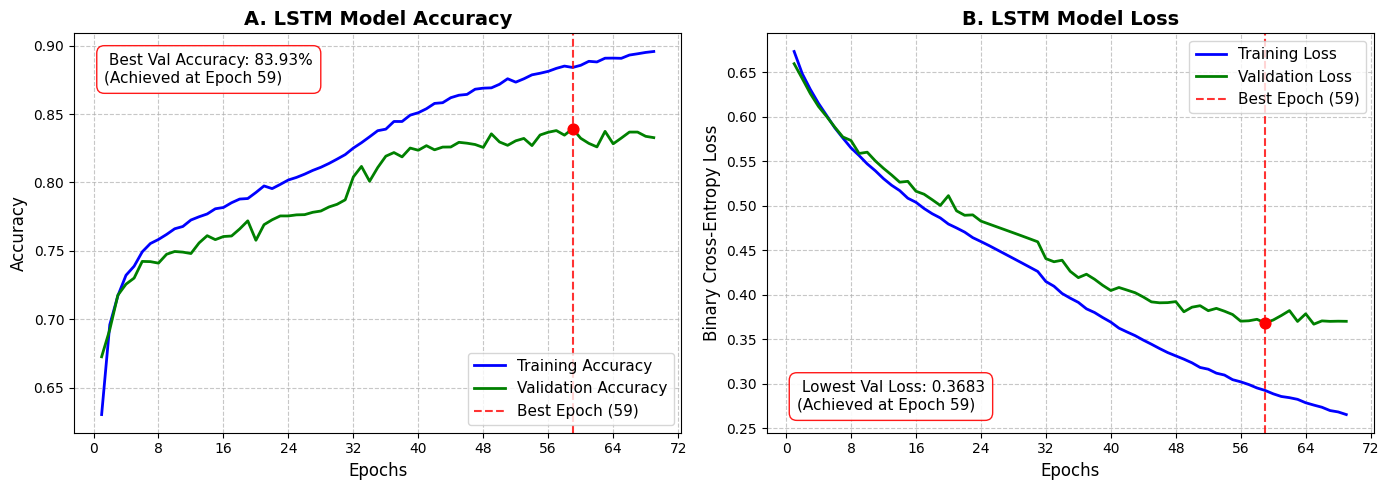

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- 1. DATA INLADEN UIT DE CSV ---
pad_csv_log = './training_geschiedenis_pieter_kopie.csv'

# Lees het logboek in
df = pd.read_csv(pad_csv_log)

# Haal de getallenlijstjes uit de kolommen
# Let op: de CSVLogger begint te tellen bij epoch 0, dus we doen +1 voor de grafiek
epochs = df['epoch'] + 1 
acc = df['accuracy']
val_acc = df['val_accuracy']
loss = df['loss']
val_loss = df['val_loss']

# Zoek de beste waarden op (idxmax zoekt de rij met de hoogste validation accuracy)
best_index = val_acc.idxmax()
best_epoch = epochs.iloc[best_index]
best_val_acc = val_acc.iloc[best_index]
best_val_loss = val_loss.iloc[best_index]

# --- 2. PLOTTEN ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Grafiek A: Accuracy
ax1.plot(epochs, acc, 'b-', label='Training Accuracy', linewidth=2)
ax1.plot(epochs, val_acc, 'g-', label='Validation Accuracy', linewidth=2)
ax1.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Epoch ({best_epoch})', alpha=0.8)
ax1.scatter(best_epoch, best_val_acc, color='red', s=60, zorder=5)

# Fix voor de X-as: forceer alleen hele getallen
ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Tekstvak voor de topscore
tekst_acc = f" Best Val Accuracy: {best_val_acc*100:.2f}%\n(Achieved at Epoch {best_epoch})"
ax1.text(0.05, 0.95, tekst_acc, transform=ax1.transAxes, fontsize=11,
         verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='red', alpha=0.9))

ax1.set_title('A. LSTM Model Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(loc='lower right', fontsize=11)

# Grafiek B: Loss
ax2.plot(epochs, loss, 'b-', label='Training Loss', linewidth=2)
ax2.plot(epochs, val_loss, 'g-', label='Validation Loss', linewidth=2)
ax2.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Epoch ({best_epoch})', alpha=0.8)
ax2.scatter(best_epoch, best_val_loss, color='red', s=60, zorder=5)

# Fix voor de X-as: forceer alleen hele getallen
ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Tekstvak voor de laagste loss
tekst_loss = f" Lowest Val Loss: {best_val_loss:.4f}\n(Achieved at Epoch {best_epoch})"
ax2.text(0.05, 0.05, tekst_loss, transform=ax2.transAxes, fontsize=11,
         verticalalignment='bottom', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='red', alpha=0.9))

ax2.set_title('B. LSTM Model Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Binary Cross-Entropy Loss', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

In [5]:
import tensorflow as tf
import glob
import os
def maak_tf_dataset(files, audio_dir):
    generator = DataGenerator(files=files, audio_dir=audio_dir, time_window=640)
    dataset = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            (tf.TensorSpec(shape=(None, 640, 64), dtype=tf.float32),
             tf.TensorSpec(shape=(None, 640, 1), dtype=tf.float32),
             tf.TensorSpec(shape=(None, 640, 1), dtype=tf.float32)),
            tf.TensorSpec(shape=(None, 1), dtype=tf.float32)
        )
    )
    return dataset

pad_naar_test_eeg = "./data/test_data/*/*.npz" 
pad_naar_test_audio = "./data/preprocessed/audio/cnn/"

pad_beste_model = './generic_lstm_alle_proefpersonen_EIND_pieter.keras'


test_files = glob.glob(pad_naar_test_eeg)
print(f" Aantal test-trials gevonden: {len(test_files)}")

if len(test_files) == 0:
    raise ValueError(" Geen testbestanden gevonden")

test_dataset = maak_tf_dataset(test_files, pad_naar_test_audio)

model = tf.keras.models.load_model(pad_beste_model)


loss, accuracy = model.evaluate(test_dataset)


print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy*100:.2f}%")


 Aantal test-trials gevonden: 100
🔍 Bezig met scannen van alle audiobestanden...
✅ 82 audiobestanden gevonden in de map!
    100/Unknown 17s 112ms/step - accuracy: 0.8656 - loss: 0.3067

WARNING    c:\school\master 1.2\git\P_D_ISSP_base-main\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
 [py.warnings]


100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - accuracy: 0.8569 - loss: 0.3248
Loss: 0.3248
Accuracy: 85.69%


In [5]:
import tensorflow as tf
import glob
import random
import numpy as np
import os
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
from tensorflow.keras.optimizers import Adam


def maak_tf_dataset(files, audio_dir):
    generator = DataGenerator(files=files, audio_dir=audio_dir, time_window=640)
    dataset = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            (tf.TensorSpec(shape=(None, 640, 64), dtype=tf.float32),
             tf.TensorSpec(shape=(None, 640, 1), dtype=tf.float32),
             tf.TensorSpec(shape=(None, 640, 1), dtype=tf.float32)),
            tf.TensorSpec(shape=(None, 1), dtype=tf.float32)
        )
    )
    return dataset

# --- 0B. HULPFUNCTIE: LSTM MODEL BOUWEN ---
def bouw_lstm_model(time_window=640, units_lstm=16, filters_cnn_eeg=8, filters_cnn_env=16, 
                    units_hidden=20, stride_temporal=3, kerSize_ver_eeg=7, kerSize_temporal=9, stride_ch=2):
    
    eeg = tf.keras.layers.Input(shape=[time_window, 64], name="EEG_Input")
    env1 = tf.keras.layers.Input(shape=[time_window, 1], name="Env1_Input")
    env2 = tf.keras.layers.Input(shape=[time_window, 1], name="Env2_Input")

    # Extra dimensie voor Conv2D
    eeg_exp = tf.keras.layers.Reshape((time_window, 64, 1))(eeg)
    env1_exp = tf.keras.layers.Reshape((time_window, 1, 1))(env1)
    env2_exp = tf.keras.layers.Reshape((time_window, 1, 1))(env2)

    eeg_bn = tf.keras.layers.BatchNormalization()(eeg_exp)
    env1_bn = tf.keras.layers.BatchNormalization()(env1_exp)
    env2_bn = tf.keras.layers.BatchNormalization()(env2_exp)

    # EEG Pad
    eeg_cnn = tf.keras.layers.Conv2D(filters_cnn_eeg, (kerSize_temporal, kerSize_ver_eeg), 
                                     strides=(stride_temporal, stride_ch), activation='tanh', name="CNN_EEG")(eeg_bn)
    eeg_cnn = tf.keras.layers.BatchNormalization()(eeg_cnn)
    
    eeg_reshaped = tf.keras.layers.Reshape((211, 232))(eeg_cnn)

    eeg_td1 = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(units_hidden, activation='tanh'), name="TD_Dense_1")(eeg_reshaped)
    eeg_td1 = tf.keras.layers.BatchNormalization()(eeg_td1)
    output_eeg = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(units_lstm, activation='tanh'), name="TD_Dense_2")(eeg_td1)

    # Audio Pad met LSTM
    env_cnn_layer = tf.keras.layers.Conv2D(filters_cnn_env, (kerSize_temporal, 1), 
                                           strides=(stride_temporal, 1), activation='tanh', name="CNN_Audio")
    
    env1_cnn = tf.keras.layers.BatchNormalization()(env_cnn_layer(env1_bn))
    env2_cnn = tf.keras.layers.BatchNormalization()(env_cnn_layer(env2_bn))

    env_reshape_layer = tf.keras.layers.Reshape((211, 16))
    env1_reshaped = env_reshape_layer(env1_cnn)
    env2_reshaped = env_reshape_layer(env2_cnn)

    lstm_layer = tf.keras.layers.LSTM(units_lstm, return_sequences=True, activation='tanh', name="LSTM_Audio")
    output_env1 = lstm_layer(env1_reshaped)
    output_env2 = lstm_layer(env2_reshaped)

    # Vergelijken
    eeg_flat = tf.keras.layers.Flatten()(output_eeg)
    env1_flat = tf.keras.layers.Flatten()(output_env1)
    env2_flat = tf.keras.layers.Flatten()(output_env2)

    cos1 = tf.keras.layers.Dot(axes=1, normalize=True, name="Cosine_Env1")([eeg_flat, env1_flat])
    cos2 = tf.keras.layers.Dot(axes=1, normalize=True, name="Cosine_Env2")([eeg_flat, env2_flat])

    concat = tf.keras.layers.Concatenate()([cos1, cos2])
    out1 = tf.keras.layers.Dense(1, activation='sigmoid', name='Decision_Neuron')(concat)
    out = tf.keras.layers.Reshape([1], name="output_name")(out1)

    model = tf.keras.Model(inputs=[eeg, env1, env2], outputs=[out])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    return model




pad_basis_model = './generic_lstm_alle_proefpersonen_EIND_pieter.keras'

pad_transfer_model = './lstm_transfer_proefpersoon2_pieter.keras'
pad_transfer_csv = './training_geschiedenis_transfer_p2_pieter.csv'

# --- 2. DATA VAN ÉÉN SPECIFIEKE PROEFPERSOON INLADEN ---
# LET OP: Pas het sterretje aan zodat hij alleen de map van 1 proefpersoon pakt!
# Bijvoorbeeld: .../train/Subject_1/*/*.npz (Kijk goed hoe je map heet)
pad_naar_eeg_p1 = "./data/64 Channel Biosemi unprocessed data - train/sub-01-10/sub-003/*.npz"

pad_naar_audio = "./data/preprocessed/audio/cnn/"

alle_eeg_bestanden_p1 = glob.glob(pad_naar_eeg_p1)
print(f"Aantal trials voor deze proefpersoon: {len(alle_eeg_bestanden_p1)}")

random.seed(42) 
random.shuffle(alle_eeg_bestanden_p1)

split_index = int(len(alle_eeg_bestanden_p1) * 0.8)
train_files_p1 = alle_eeg_bestanden_p1[:split_index]
val_files_p1 = alle_eeg_bestanden_p1[split_index:]

train_dataset_p1 = maak_tf_dataset(train_files_p1, pad_naar_audio)
val_dataset_p1 = maak_tf_dataset(val_files_p1, pad_naar_audio)


model_transfer = tf.keras.models.load_model(pad_basis_model)

# CRUCIAAL: We compileren het model opnieuw met een LAGERE learning rate (bijv. 1e-4)
# Standaard is het 1e-3 (0.001). We maken hem nu 10x zo traag (0.0001) zodat hij voorzichtig leert.
model_transfer.compile(
    optimizer=Adam(learning_rate=1e-4), 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

checkpoint = ModelCheckpoint(
    filepath=pad_transfer_model,
    monitor='val_accuracy',
    save_best_only=True, 
    verbose=1
)

csv_logger = CSVLogger(pad_transfer_csv, append=False) # append=False want het is een vers logboek

early_stop = EarlyStopping(
    monitor='val_accuracy', 
    patience=5, # Na 5 slechte epochs stoppen we direct
    restore_best_weights=True,
    verbose=1
)

geschiedenis_transfer = model_transfer.fit(
    train_dataset_p1,
    validation_data=val_dataset_p1,
    epochs=20, 
    callbacks=[early_stop, checkpoint, csv_logger] 
)



Aantal trials voor deze proefpersoon: 9
🔍 Bezig met scannen van alle audiobestanden...
✅ 82 audiobestanden gevonden in de map!
🔍 Bezig met scannen van alle audiobestanden...
✅ 82 audiobestanden gevonden in de map!
Epoch 1/20
      7/Unknown 50s 2s/step - accuracy: 0.8971 - loss: 0.2760
Epoch 1: val_accuracy improved from None to 0.89506, saving model to ./lstm_transfer_proefpersoon2_pieter.keras

Epoch 1: finished saving model to ./lstm_transfer_proefpersoon2_pieter.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 59s 4s/step - accuracy: 0.8915 - loss: 0.2685 - val_accuracy: 0.8951 - val_loss: 0.2840
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9113 - loss: 0.2376
Epoch 2: val_accuracy did not improve from 0.89506
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.9009 - loss: 0.2580 - val_accuracy: 0.8951 - val_loss: 0.2822
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9038 - loss: 0.2593
Epoch 3: val_accuracy improved from 0.89506 to 0.89815, saving model to ./lstm_trans

In [10]:

pad_generic_model = './generic_lstm_alle_proefpersonen_EIND_pieter.keras'
pad_transfer_model = './lstm_transfer_proefpersoon2_pieter.keras'

pad_naar_test_eeg_sub003 = "./data/test_data/sub-003/*.npz" 
pad_naar_test_audio = "./data/preprocessed/audio/cnn/"

# --- 2. TEST DATA KLAARMAKEN ---
test_files = glob.glob(pad_naar_test_eeg_sub003)
print(f"\n Aantal test-trials gevonden voor SUB-003: {len(test_files)}")

if len(test_files) == 0:
    raise ValueError(" Geen testbestanden gevonden voor sub-003")

test_dataset = maak_tf_dataset(test_files, pad_naar_test_audio)

model_generic = tf.keras.models.load_model(pad_generic_model)
loss_gen, acc_gen = model_generic.evaluate(test_dataset, verbose=1)

model_transfer = tf.keras.models.load_model(pad_transfer_model)
loss_trans, acc_trans = model_transfer.evaluate(test_dataset, verbose=1)


print(f"Generic LSTM Model:         Accuracy = {acc_gen * 100:.2f}%  | Loss = {loss_gen:.4f}")
print(f"Transfer Learning LSTM:     Accuracy = {acc_trans * 100:.2f}%  | Loss = {loss_trans:.4f}")

verschil = (acc_trans - acc_gen) * 100
if verschil > 0:
    print(f" Verbetering: {verschil:.2f}%")
else:
    print(f" Conclusie: Transfer Learning gaf geen accuracy-verbetering ({verschil:.2f}%)")



 Aantal test-trials gevonden voor SUB-003: 1
🔍 Bezig met scannen van alle audiobestanden...
✅ 82 audiobestanden gevonden in de map!
      1/Unknown 14s 14s/step - accuracy: 0.9167 - loss: 0.1835

WARNING    c:\school\master 1.2\git\P_D_ISSP_base-main\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
 [py.warnings]


1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - accuracy: 0.9167 - loss: 0.1835
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 0.9583 - loss: 0.1659
Generic LSTM Model:         Accuracy = 91.67%  | Loss = 0.1835
Transfer Learning LSTM:     Accuracy = 95.83%  | Loss = 0.1659
 Verbetering: 4.17%


In [11]:
import tensorflow as tf
import glob
import random
import numpy as np
import os
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# --- 1. SETUP VOOR DE LOOP ---
pad_basis_model = './generic_lstm_alle_proefpersonen_EIND_pieter.keras'
pad_naar_audio = "./data/preprocessed/audio/cnn/"

lijst_proefpersonen = ["sub-004", "sub-005", "sub-006", "sub-007"] 

eind_resultaten = {}


for subject in lijst_proefpersonen:
    print(f" BEZIG MET PROEFPERSOON: {subject}")


    pad_train_eeg = f"./data/64 Channel Biosemi unprocessed data - train/sub-01-10/{subject}/*.npz"
    pad_test_eeg = f"./data/test_data/{subject}/*.npz"
    pad_transfer_model = f'./lstm_transfer_{subject}_pieter.keras'

    train_files_all = glob.glob(pad_train_eeg)
    test_files = glob.glob(pad_test_eeg)

    if len(train_files_all) == 0 or len(test_files) == 0:
        print(f" Data ontbreekt voor {subject}. We slaan deze over")
        continue # Gaat direct door naar de volgende proefpersoon

    random.seed(42)
    random.shuffle(train_files_all)
    split_index = int(len(train_files_all) * 0.8)
    
    train_dataset = maak_tf_dataset(train_files_all[:split_index], pad_naar_audio)
    val_dataset = maak_tf_dataset(train_files_all[split_index:], pad_naar_audio)
    test_dataset = maak_tf_dataset(test_files, pad_naar_audio)


    model_transfer = tf.keras.models.load_model(pad_basis_model)
    
    model_transfer.compile(
        optimizer=Adam(learning_rate=1e-4), 
        loss='binary_crossentropy', 
        metrics=['accuracy']
    )

    checkpoint = ModelCheckpoint(filepath=pad_transfer_model, monitor='val_accuracy', save_best_only=True, verbose=0)
    early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=0)

    print(f"Start finetunen voor {subject}...")
    model_transfer.fit(train_dataset, validation_data=val_dataset, epochs=15, callbacks=[early_stop, checkpoint], verbose=0)

    print(f"Testen van GENERIC model op {subject}...")
    model_generic = tf.keras.models.load_model(pad_basis_model)
    loss_gen, acc_gen = model_generic.evaluate(test_dataset, verbose=0)

    print(f"Testen van TRANSFER model op {subject}...")
    model_transfer_best = tf.keras.models.load_model(pad_transfer_model)
    loss_trans, acc_trans = model_transfer_best.evaluate(test_dataset, verbose=0)

    eind_resultaten[subject] = {
        'Generic_Acc': acc_gen * 100,
        'Transfer_Acc': acc_trans * 100,
        'Verschil': (acc_trans - acc_gen) * 100
    }
    
    print(f"-> Resultaat {subject}: Generic = {acc_gen*100:.1f}% | Transfer = {acc_trans*100:.1f}%")

    #  Voorkom dat je RAM geheugen crasht door alle modellen te wissen!
    tf.keras.backend.clear_session()



gemiddelde_winst = []

for subject, scores in eind_resultaten.items():
    gen = scores['Generic_Acc']
    trans = scores['Transfer_Acc']
    diff = scores['Verschil']
    gemiddelde_winst.append(diff)
    
    teken = "+" if diff > 0 else ""
    print(f"{subject}: Generic = {gen:.2f}% | Transfer = {trans:.2f}% | Verschil = {teken}{diff:.2f}%")

avg_diff = np.mean(gemiddelde_winst)


 BEZIG MET PROEFPERSOON: sub-004
🔍 Bezig met scannen van alle audiobestanden...
✅ 82 audiobestanden gevonden in de map!
🔍 Bezig met scannen van alle audiobestanden...
✅ 82 audiobestanden gevonden in de map!
🔍 Bezig met scannen van alle audiobestanden...
✅ 82 audiobestanden gevonden in de map!
Start finetunen voor sub-004...
Testen van GENERIC model op sub-004...
Testen van TRANSFER model op sub-004...
-> Resultaat sub-004: Generic = 79.2% | Transfer = 83.3%

 BEZIG MET PROEFPERSOON: sub-005
🔍 Bezig met scannen van alle audiobestanden...
✅ 82 audiobestanden gevonden in de map!
🔍 Bezig met scannen van alle audiobestanden...
✅ 82 audiobestanden gevonden in de map!
🔍 Bezig met scannen van alle audiobestanden...
✅ 82 audiobestanden gevonden in de map!
Start finetunen voor sub-005...
Testen van GENERIC model op sub-005...
Testen van TRANSFER model op sub-005...
-> Resultaat sub-005: Generic = 87.5% | Transfer = 91.7%
 BEZIG MET PROEFPERSOON: sub-006
🔍 Bezig met scannen van alle audiobestande